<a href="https://colab.research.google.com/github/zinebidrissijanati1-debug/ERF-REPO/blob/main/ERF_selection_operator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


=== Selection: Tournament ===
Selected Features: [ 1  4  7  8 14 15 17 18 19 21 23 24 26]
Accuracy: 0.9842
Confusion Matrix:
[[204   8]
 [  1 356]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.96      0.98       212
           1       0.98      1.00      0.99       357

    accuracy                           0.98       569
   macro avg       0.99      0.98      0.98       569
weighted avg       0.98      0.98      0.98       569


=== Selection: Roulette ===
Selected Features: [ 1  7  9 15 21 23 24 26 28]
Accuracy: 0.9772
Confusion Matrix:
[[203   9]
 [  4 353]]
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.96      0.97       212
           1       0.98      0.99      0.98       357

    accuracy                           0.98       569
   macro avg       0.98      0.97      0.98       569
weighted avg       0.98      0.98      0.98       569



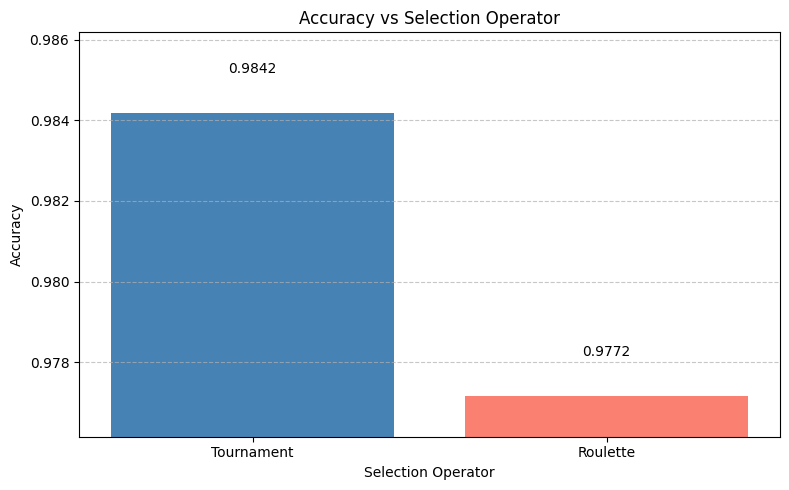

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load dataset
data = load_breast_cancer()
X, y = data.data, data.target
n_features = X.shape[1]

# Constants
iterations = 20
pop_size = 100
mutation_rate = 0.1
n_estimators = 50
max_depth = None
criterion = 'gini'
bootstrap = True
random_state = 0

# GA Components
def initial_population(size, length):
    return [np.random.randint(2, size=length) for _ in range(size)]

def decode_chromosome(chromosome):
    return np.where(chromosome == 1)[0]

def tournament_selection(pop, scores):
    next_gen = []
    for _ in range(len(pop)):
        i1, i2 = np.random.randint(0, len(pop), 2)
        winner = pop[i1] if scores[i1] > scores[i2] else pop[i2]
        next_gen.append(winner)
    return next_gen

def roulette_selection(pop, scores):
    next_gen = []
    total_score = sum(scores)
    probs = [s / total_score for s in scores]
    for _ in range(len(pop)):
        idx = np.random.choice(len(pop), p=probs)
        next_gen.append(pop[idx])
    return next_gen

def one_point_crossover(pop):
    children = []
    for i in range(0, len(pop), 2):
        if i + 1 < len(pop):
            p1, p2 = pop[i], pop[i+1]
            point = np.random.randint(1, len(p1))
            c1 = np.concatenate((p1[:point], p2[point:]))
            c2 = np.concatenate((p2[:point], p1[point:]))
            children.extend([c1, c2])
        else:
            children.append(pop[i])
    return children

def mutation(pop, rate):
    mutated = []
    for individual in pop:
        if np.random.rand() < rate:
            idx = np.random.randint(len(individual))
            individual[idx] = 1 - individual[idx]
        mutated.append(individual)
    return mutated

def cross_val_fitness(chromosome):
    selected = decode_chromosome(chromosome)
    if len(selected) == 0:
        return 0.0
    kf = KFold(n_splits=5, shuffle=True, random_state=random_state)
    scores = []
    for train_idx, test_idx in kf.split(X):
        model = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            criterion=criterion,
            bootstrap=bootstrap,
            random_state=random_state
        )
        model.fit(X[train_idx][:, selected], y[train_idx])
        preds = model.predict(X[test_idx][:, selected])
        scores.append(accuracy_score(y[test_idx], preds))
    return np.mean(scores)

# Run for both selection operators
results = {}
for sel_name, sel_func in [('Tournament', tournament_selection), ('Roulette', roulette_selection)]:
    print(f"\n=== Selection: {sel_name} ===")
    start_time = time.time()

    population = initial_population(pop_size, n_features)
    best_individual = None
    best_score = 0

    for gen in range(iterations):
        scores = [cross_val_fitness(ind) for ind in population]
        max_idx = np.argmax(scores)
        if scores[max_idx] > best_score:
            best_score = scores[max_idx]
            best_individual = population[max_idx]
        population = sel_func(population, scores)
        population = one_point_crossover(population)
        population = mutation(population, mutation_rate)

    selected_features = decode_chromosome(best_individual)
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        criterion=criterion,
        bootstrap=bootstrap,
        random_state=random_state
    )
    kf = KFold(n_splits=5, shuffle=True, random_state=random_state)
    all_preds, all_true = [], []

    for train_idx, test_idx in kf.split(X):
        model.fit(X[train_idx][:, selected_features], y[train_idx])
        preds = model.predict(X[test_idx][:, selected_features])
        all_preds.extend(preds)
        all_true.extend(y[test_idx])

    accuracy = accuracy_score(all_true, all_preds)
    cm = confusion_matrix(all_true, all_preds)
    report = classification_report(all_true, all_preds, output_dict=True)

    end_time = time.time()
    duration = end_time - start_time

    results[sel_name] = {
        "accuracy": accuracy,
        "confusion_matrix": cm,
        "report": report,
        "features": selected_features,
        "time": duration
    }

    print(f"Selected Features: {selected_features}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Confusion Matrix:\n{cm}")
    print("Classification Report:")
    print(classification_report(all_true, all_preds))

# Optional: Plot results
plt.figure(figsize=(8, 5))
selection_names = list(results.keys())
accuracies = [results[name]['accuracy'] for name in selection_names]

bars = plt.bar(selection_names, accuracies, color=['steelblue', 'salmon'])
for bar, acc in zip(bars, accuracies):
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.001, f"{acc:.4f}", ha='center')

plt.title('Accuracy vs Selection Operator')
plt.xlabel('Selection Operator')
plt.ylabel('Accuracy')
plt.ylim(min(accuracies) - 0.001, max(accuracies) + 0.002)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
